In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import mstats
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (accuracy_score, precision_score,recall_score, f1_score,roc_auc_score, confusion_matrix,classification_report)
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

In [ ]:
import kagglehub

path = kagglehub.dataset_download("priyamchoksi/100000-diabetes-clinical-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the '100000-diabetes-clinical-dataset' dataset.
Path to dataset files: /kaggle/input/100000-diabetes-clinical-dataset


In [ ]:
os.listdir(path)

['diabetes_dataset.csv']

# EDA

In [ ]:
df = pd.read_csv(path + "/diabetes_dataset.csv")

df.head(20)

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0
5,2016,Male,66.0,Alabama,0,0,1,0,0,0,0,not current,27.32,5.7,159,0
6,2015,Female,49.0,Alabama,0,0,1,0,0,0,0,current,24.34,5.7,80,0
7,2016,Female,15.0,Alabama,0,0,0,0,1,0,0,No Info,20.98,5.0,155,0
8,2016,Male,51.0,Alabama,1,0,0,0,0,0,0,never,38.14,6.0,100,0
9,2015,Male,42.0,Alabama,0,0,1,0,0,0,0,No Info,27.32,5.7,160,0


In [ ]:
df.shape

(100000, 16)

In [ ]:
df.columns

Index(['year', 'gender', 'age', 'location', 'race:AfricanAmerican',
       'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other',
       'hypertension', 'heart_disease', 'smoking_history', 'bmi',
       'hbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  d

In [ ]:
df.nunique()

,0
year,7
gender,3
age,102
location,55
race:AfricanAmerican,2
race:Asian,2
race:Caucasian,2
race:Hispanic,2
race:Other,2
hypertension,2


In [ ]:
df.describe(include='all')

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000,100000.000000,100000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,100000.000000,100000,100000.000000,100000.000000,100000.000000,100000.000000
unique,NaN,3,NaN,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN
top,NaN,Female,NaN,Kentucky,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Info,NaN,NaN,NaN,NaN
freq,NaN,58552,NaN,2038,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35816,NaN,NaN,NaN,NaN
mean,2018.360820,NaN,41.885856,NaN,0.202230,0.200150,0.198760,0.19888,0.199980,0.07485,0.039420,NaN,27.320767,5.527507,138.058060,0.085000
std,1.345239,NaN,22.516840,NaN,0.401665,0.400114,0.399069,0.39916,0.399987,0.26315,0.194593,NaN,6.636783,1.070672,40.708136,0.278883
min,2015.000000,NaN,0.080000,NaN,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,NaN,10.010000,3.500000,80.000000,0.000000
25%,2019.000000,NaN,24.000000,NaN,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,NaN,23.630000,4.800000,100.000000,0.000000
50%,2019.000000,NaN,43.000000,NaN,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,NaN,27.320000,5.800000,140.000000,0.000000
75%,2019.000000,NaN,60.000000,NaN,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,NaN,29.580000,6.200000,159.000000,0.000000


In [ ]:
df.isnull().sum()

,0
year,0
gender,0
age,0
location,0
race:AfricanAmerican,0
race:Asian,0
race:Caucasian,0
race:Hispanic,0
race:Other,0
hypertension,0


In [ ]:
df.duplicated().sum()

np.int64(14)

diabetes
0    91500
1     8500
Name: count, dtype: int64


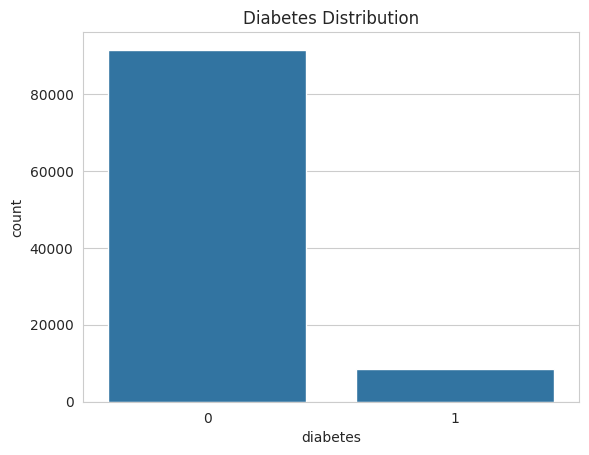

In [ ]:
print(df['diabetes'].value_counts())
sns.countplot(x='diabetes', data=df)
plt.title("Diabetes Distribution")
plt.show()

age
80.00    5621
51.00    1619
47.00    1574
48.00    1568
53.00    1542
         ... 
0.48       83
1.00       83
0.40       66
0.16       59
0.08       36
Name: count, Length: 102, dtype: int64


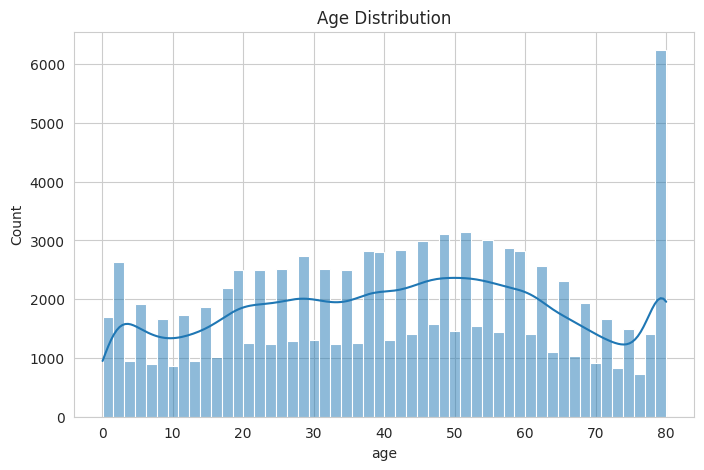

In [ ]:
print(df['age'].value_counts())
plt.figure(figsize=(8,5))
sns.histplot(df['age'],kde=True)
plt.title("Age Distribution")
plt.show()

In [ ]:
df['age'].min(), df['age'].max()

(0.08, 80.0)

In [ ]:
#median_age = df['age'].median()
#df['age'] = df['age'].apply(lambda x: median_age if x < 1 else x)

In [ ]:
#print(df['age'].value_counts())
#df['age'].describe()
#sns.histplot(df['age'], bins=30, kde=True)
#plt.title("Age Distribution After Cleaning")
#plt.show()

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64


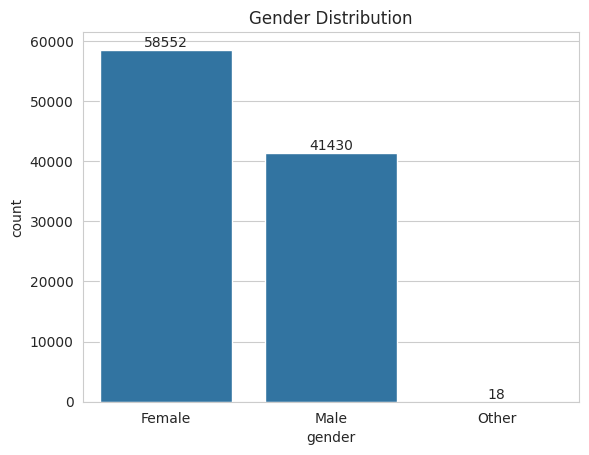

In [ ]:
print(df['gender'].value_counts())
ax = sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.show()

bmi
27.32    25495
23.00      103
27.12      101
24.96      100
27.80      100
         ...  
49.80        1
45.62        1
68.61        1
52.25        1
61.29        1
Name: count, Length: 4247, dtype: int64


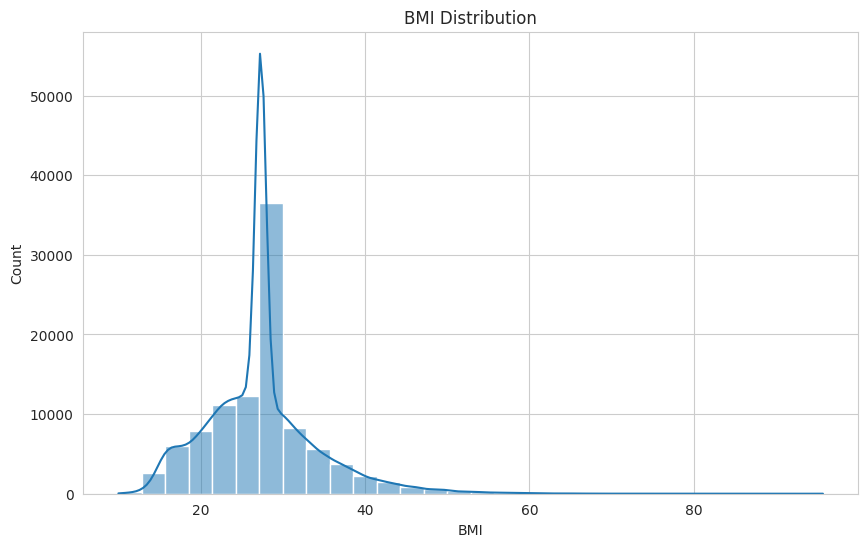

In [ ]:
print(df['bmi'].value_counts())
plt.figure(figsize=(10,6))
sns.histplot(df['bmi'], bins=30, kde=True)  # bins=30 groups BMI into 30 ranges
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

blood_glucose_level
130    7794
159    7759
140    7732
160    7712
126    7702
145    7679
200    7600
155    7575
90     7112
80     7106
158    7026
100    7025
85     6901
280     729
300     674
240     636
260     635
220     603
Name: count, dtype: int64


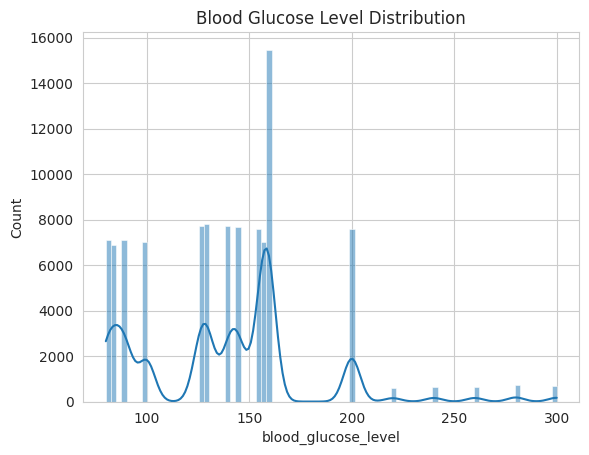

In [ ]:
print(df['blood_glucose_level'].value_counts())
sns.histplot(df['blood_glucose_level'], kde=True)
plt.title("Blood Glucose Level Distribution")
plt.show()

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


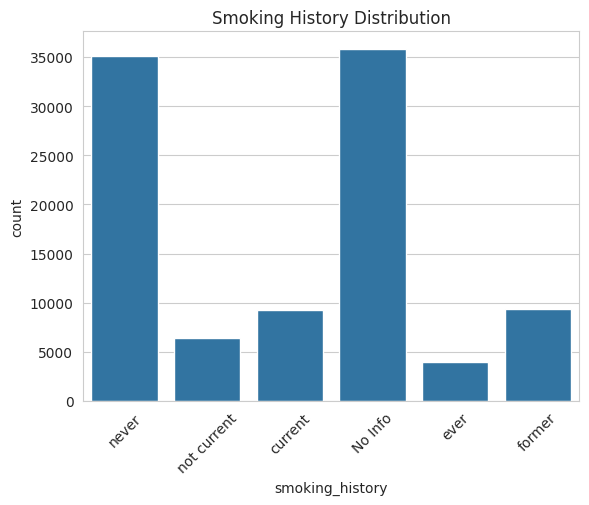

In [ ]:
print(df['smoking_history'].value_counts())

sns.countplot(x='smoking_history', data=df)
plt.title("Smoking History Distribution")
plt.xticks(rotation=45)
plt.show()

year
2015     8760
2016     8760
2018     2678
2019    79745
2020       42
2021        7
2022        8
Name: count, dtype: int64


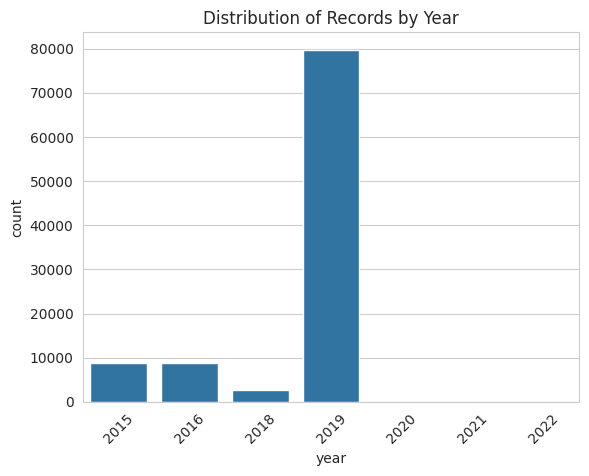

In [ ]:
print(df['year'].value_counts().sort_index())

sns.countplot(x='year', data=df)
plt.title("Distribution of Records by Year")
plt.xticks(rotation=45)
plt.show()

hbA1c_level
6.6    8540
5.7    8413
6.5    8362
5.8    8321
6.0    8295
6.2    8269
6.1    8048
3.5    7662
4.8    7597
4.5    7585
4.0    7542
5.0    7471
8.2     661
8.8     661
9.0     654
7.5     643
6.8     642
7.0     634
Name: count, dtype: int64


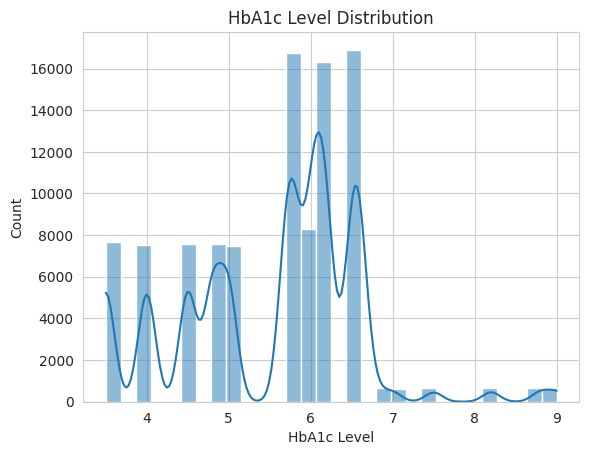

In [ ]:
print(df['hbA1c_level'].value_counts())

sns.histplot(df['hbA1c_level'], bins=30, kde=True)
plt.title("HbA1c Level Distribution")
plt.xlabel("HbA1c Level")
plt.show()

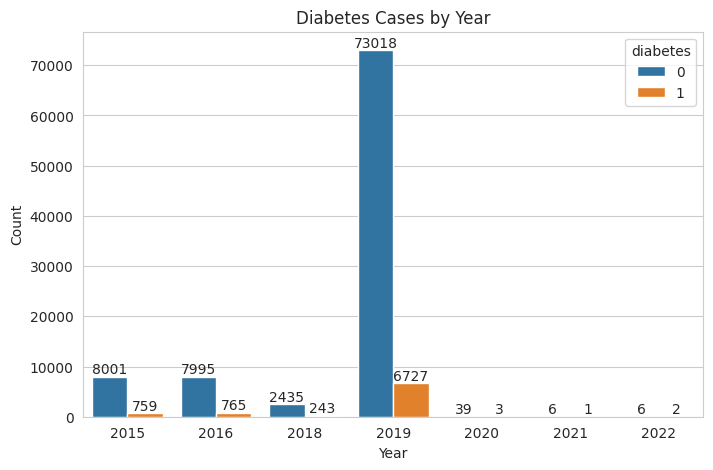

In [ ]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x='year', hue='diabetes', data=df)
plt.title("Diabetes Cases by Year")
plt.xlabel("Year")
plt.ylabel("Count")

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10)

plt.show()

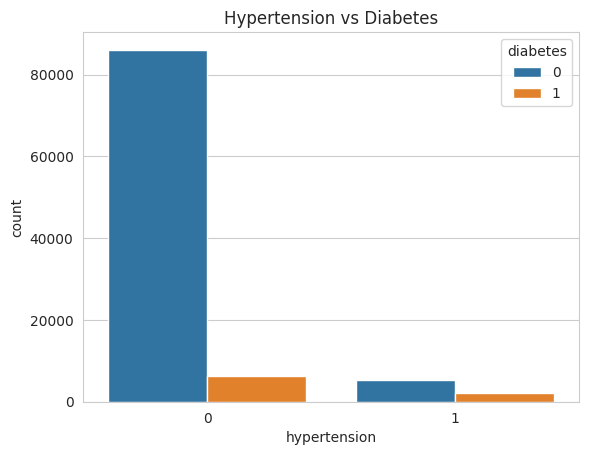

In [ ]:
sns.countplot(x='hypertension', hue='diabetes', data=df)
plt.title("Hypertension vs Diabetes")
plt.show()

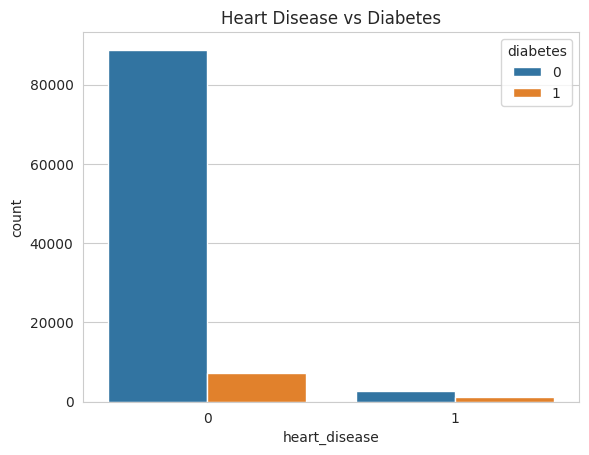

In [ ]:
sns.countplot(x='heart_disease', hue='diabetes', data=df)
plt.title("Heart Disease vs Diabetes")
plt.show()

In [ ]:
race_cols = ['race:AfricanAmerican','race:Asian','race:Caucasian','race:Hispanic','race:Other']

df['race'] = df[race_cols].idxmax(axis=1)
df['race'] = df['race'].str.replace('race:', '')

race
AfricanAmerican    20223
Asian              20015
Other              19998
Hispanic           19888
Caucasian          19876
Name: count, dtype: int64


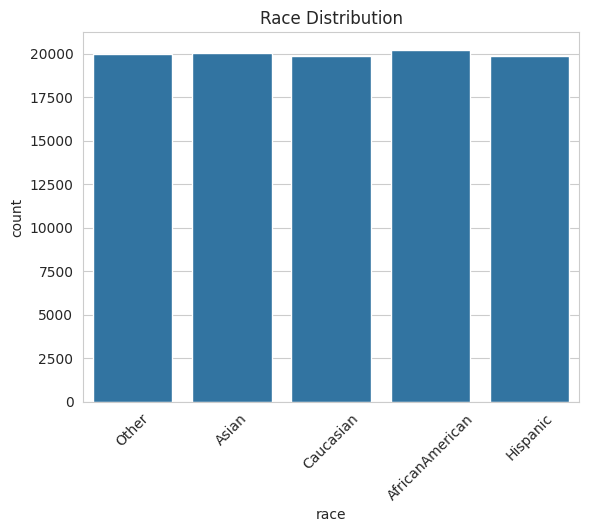

In [ ]:
print(df['race'].value_counts())
sns.countplot(x='race', data=df)
plt.title("Race Distribution")
plt.xticks(rotation=45)
plt.show()

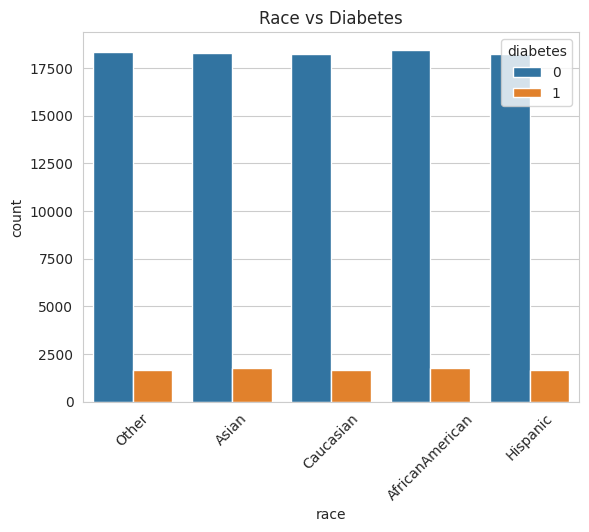

In [ ]:
sns.countplot(x='race', hue='diabetes', data=df)
plt.title("Race vs Diabetes")
plt.xticks(rotation=45)
plt.show()

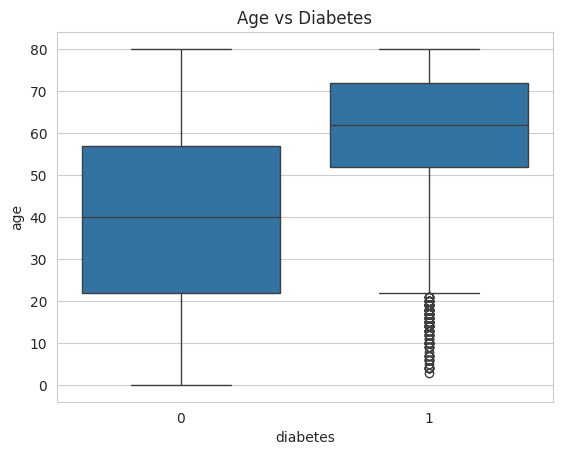

In [ ]:
sns.boxplot(x='diabetes', y='age', data=df)
plt.title("Age vs Diabetes")
plt.show()

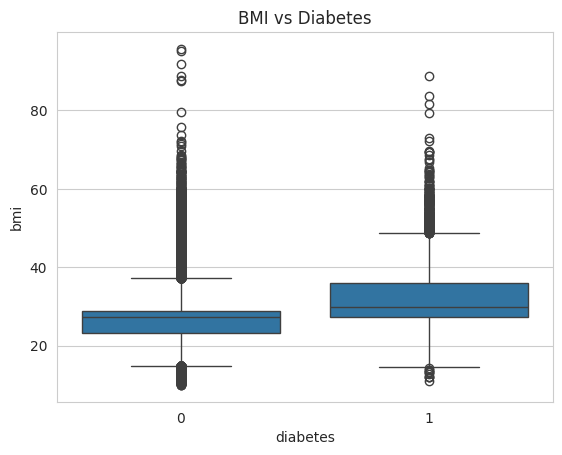

In [ ]:
sns.boxplot(x='diabetes', y='bmi', data=df)   #outlayers komaite hobe karon atar jonno biasness
plt.title("BMI vs Diabetes")
plt.show()

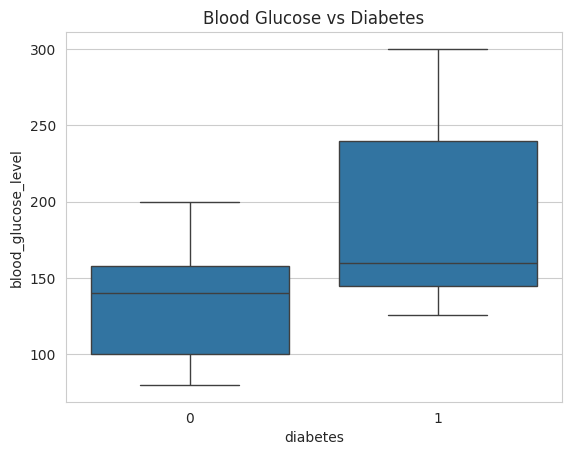

In [ ]:
sns.boxplot(x='diabetes', y='blood_glucose_level', data=df)
plt.title("Blood Glucose vs Diabetes")
plt.show()

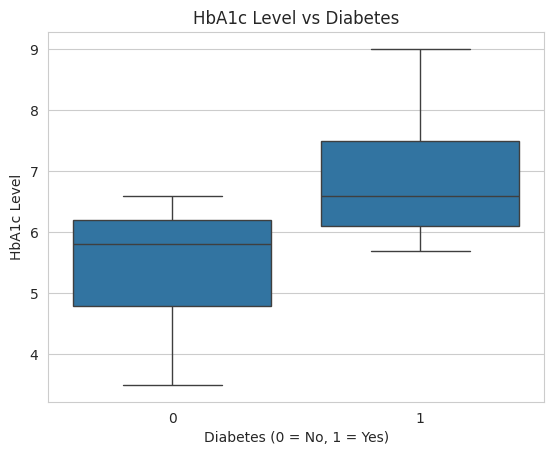

In [ ]:
sns.boxplot(x='diabetes', y='hbA1c_level', data=df)

plt.title("HbA1c Level vs Diabetes")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("HbA1c Level")

plt.show()

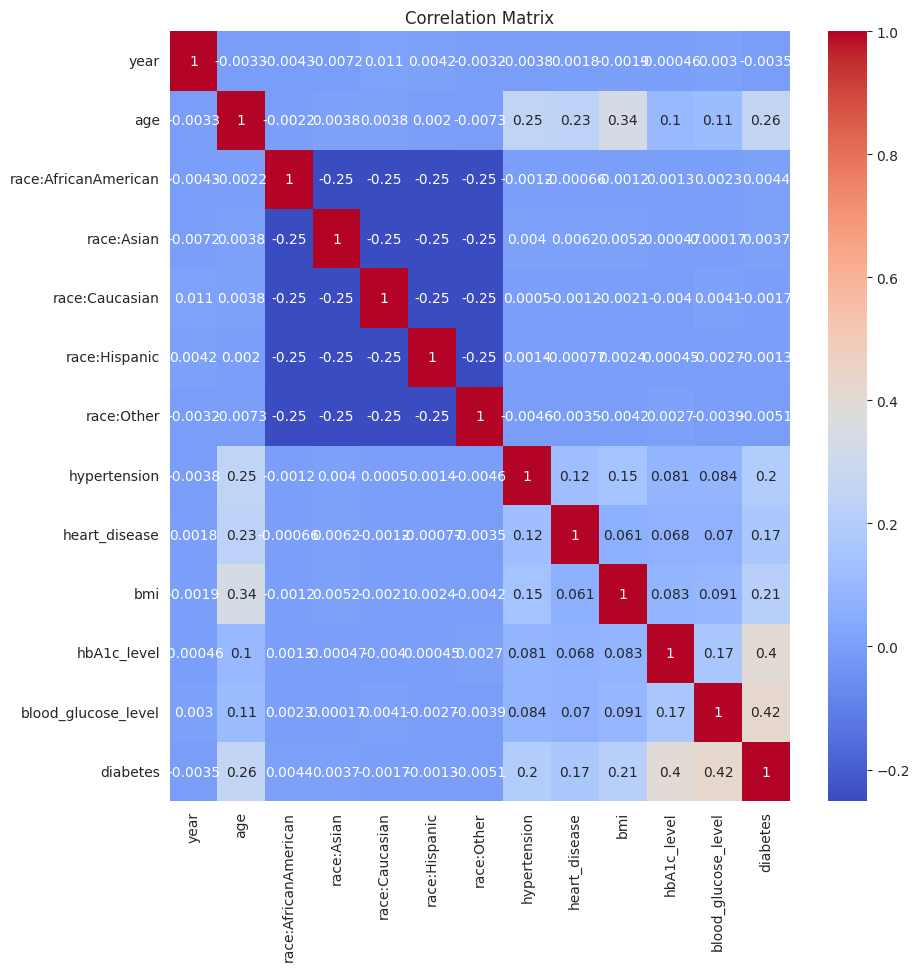

In [ ]:
plt.figure(figsize=(10,10))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

**Data Preprocessing**

In [ ]:
#df['age'].min(), df['age'].max()

In [ ]:
df = df[df['age'] >= 1]  #removed ages less than 1 # replace ages less than 1 with minimum value # or keep it up like that

In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()   #RobustScaler is specifically designed for data with outliers              #StandardScaler is sensitive to outliers tai use kori nai
df['age_scaled'] = scaler.fit_transform(df[['age']])


print(df[['age', 'age_scaled']].describe())
print(df['age_scaled'].head(10))

                age    age_scaled
count  99089.000000  99089.000000
mean      42.266093     -0.020386
std       22.266528      0.618515
min        1.000000     -1.166667
25%       24.000000     -0.527778
50%       43.000000      0.000000
75%       60.000000      0.472222
max       80.000000      1.027778
0   -0.305556
1   -0.388889
2   -0.694444
3   -0.055556
4    0.250000
5    0.638889
6    0.166667
7   -0.777778
8    0.222222
9   -0.027778
Name: age_scaled, dtype: float64


In [ ]:
df = df[df['gender'] != 'Other']  # others remove korsi as just 18 ta row # other k major group diye replace korte partam
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})

In [ ]:
# Check for biologically impossible BMI values
#print(df[df['bmi'] < 10])   # Too low
#print(df[df['bmi'] > 60])   # Extreme outliers

In [ ]:
# Cap at 1st and 99th percentile        GPT ASK
lower = df['bmi'].quantile(0.01)
upper = df['bmi'].quantile(0.99)
df['bmi'] = df['bmi'].clip(lower, upper)

In [ ]:
# Replace with NaN and re-impute
df['bmi'] = df['bmi'].replace(27.32, np.nan)

# median impute per diabetes group
df['bmi'] = df.groupby('diabetes')['bmi'].transform(
    lambda x: x.fillna(x.median())   #null kore median impute korsi
)

In [ ]:
scaler = RobustScaler()
df['bmi_scaled'] = scaler.fit_transform(df[['bmi']])

In [ ]:
bins = [0, 18.5, 24.9, 29.9, 34.9, 100]
labels = ['Underweight', 'Normal', 'Overweight', 'Obese_I', 'Obese_II+']
df['bmi_category'] = pd.cut(df['bmi'], bins=bins, labels=labels)

In [ ]:
smoking_map = {'never': 0,'No Info': 1,'former': 2,'not current': 2,'ever': 2,'current': 3}
df['smoking_history'] = df['smoking_history'].map(smoking_map)

In [ ]:
#if year actually correlates with diabetes
print(df.groupby('year')['diabetes'].mean().round(3))

year
2015    0.088
2016    0.088
2018    0.092
2019    0.085
2020    0.071
2021    0.143
2022    0.250
Name: diabetes, dtype: float64


In [ ]:
# Drop year as it adds noise     from confussion matrix so dropped
df.drop(columns=['year'], inplace=True)
print(df.shape)

(99071, 19)


In [ ]:
print(df.groupby('hbA1c_level')['diabetes'].mean().round(3))

#distribution
#df['hbA1c_level'].hist(bins=30)
#plt.title('HbA1c Distribution')
#plt.show()

hbA1c_level
3.5    0.000
4.0    0.000
4.5    0.000
4.8    0.000
5.0    0.000
5.7    0.085
5.8    0.080
6.0    0.079
6.1    0.082
6.2    0.079
6.5    0.074
6.6    0.081
6.8    1.000
7.0    1.000
7.5    1.000
8.2    1.000
8.8    1.000
9.0    1.000
Name: diabetes, dtype: float64


In [ ]:
#Does hbA1c alone predicts diabetes perfectly

simple_pred = (df['hbA1c_level'] >= 6.8).astype(int)
print(accuracy_score(df['diabetes'], simple_pred))
# Data leakage   too perfect

0.9535181839286976


In [ ]:
#from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df['hbA1c_scaled'] = scaler.fit_transform(df[['hbA1c_level']])
df['blood_glucose_scaled'] = scaler.fit_transform(df[['blood_glucose_level']])

In [ ]:
simple_pred2 = (df['blood_glucose_level'] >= 200).astype(int)
print(f"Blood glucose alone accuracy: {accuracy_score(df['diabetes'], simple_pred2):.4f}")


print(df.groupby('blood_glucose_level')['diabetes'].mean().round(3))

Blood glucose alone accuracy: 0.8843
blood_glucose_level
80     0.000
85     0.000
90     0.000
100    0.000
126    0.083
130    0.090
140    0.082
145    0.087
155    0.080
158    0.000
159    0.087
160    0.091
200    0.086
220    1.000
240    1.000
260    1.000
280    1.000
300    1.000
Name: diabetes, dtype: float64


In [ ]:
df['blood_glucose_scaled'] = RobustScaler().fit_transform(df[['blood_glucose_level']])

print(df[['hbA1c_scaled', 'blood_glucose_scaled']].describe())

       hbA1c_scaled  blood_glucose_scaled
count  99071.000000          99071.000000
mean      -0.193490             -0.032126
std        0.765181              0.690901
min       -1.642857             -1.016949
25%       -0.714286             -0.677966
50%        0.000000              0.000000
75%        0.285714              0.322034
max        2.285714              2.711864


In [ ]:
print(df.groupby('hypertension')['diabetes'].mean().round(3))

hypertension
0    0.070
1    0.279
Name: diabetes, dtype: float64


In [ ]:
# Already binary
print(df['hypertension'].dtype)
print(df['hypertension'].value_counts())

int64
hypertension
0    91586
1     7485
Name: count, dtype: int64


In [ ]:
print(df['diabetes'].value_counts())
print(df['diabetes'].value_counts(normalize=True).round(3))

diabetes
0    90571
1     8500
Name: count, dtype: int64
diabetes
0    0.914
1    0.086
Name: proportion, dtype: float64


In [ ]:
print(df.groupby('heart_disease')['diabetes'].mean().round(3))
print(df['heart_disease'].dtype)
print(df['heart_disease'].value_counts())

heart_disease
0    0.076
1    0.321
Name: diabetes, dtype: float64
int64
heart_disease
0    95129
1     3942
Name: count, dtype: int64


In [ ]:
print(df['location'].nunique())
print(df['location'].value_counts())

55
location
Arkansas                2026
Nebraska                2026
Hawaii                  2025
Minnesota               2024
Louisiana               2023
Connecticut             2022
Georgia                 2022
New York                2021
North Dakota            2020
Oregon                  2019
New Jersey              2019
Florida                 2019
Pennsylvania            2019
Illinois                2019
Kansas                  2019
New Hampshire           2018
Maryland                2018
Delaware                2018
District of Columbia    2018
Colorado                2018
Kentucky                2018
Massachusetts           2017
Rhode Island            2017
Maine                   2016
Michigan                2016
Mississippi             2014
North Carolina          2013
Alabama                 2013
Missouri                2012
Montana                 2011
Iowa                    2010
Alaska                  2010
New Mexico              2009
South Dakota            2009
Oh

In [ ]:
# Check if location actually correlates with diabetes
print(df.groupby('location')['diabetes'].mean().round(3).sort_values(ascending=False).head(10))
print(df.groupby('location')['diabetes'].mean().round(3).sort_values(ascending=False).tail(10))

location
Delaware          0.099
Kansas            0.099
Illinois          0.097
Montana           0.096
Kentucky          0.095
West Virginia     0.095
United States     0.095
Rhode Island      0.095
Virgin Islands    0.095
Tennessee         0.094
Name: diabetes, dtype: float64
location
Massachusetts     0.079
North Carolina    0.079
South Dakota      0.079
Ohio              0.078
Idaho             0.076
New Hampshire     0.075
Oklahoma          0.072
Arizona           0.071
New York          0.069
Wisconsin         0.065
Name: diabetes, dtype: float64


In [ ]:
df.drop(columns=['location'], inplace=True)
print(df.shape)  # should have one less column

(99071, 20)


In [ ]:
# Check diabetes rate by race
print(df.groupby('race')['diabetes'].mean().round(3).sort_values(ascending=False))

print(df['race'].value_counts())

race
AfricanAmerican    0.088
Asian              0.088
Caucasian          0.085
Hispanic           0.085
Other              0.083
Name: diabetes, dtype: float64
race
AfricanAmerican    20015
Asian              19854
Other              19811
Hispanic           19696
Caucasian          19695
Name: count, dtype: int64


In [ ]:
df.drop(columns=['race:AfricanAmerican', 'race:Asian',
                 'race:Caucasian', 'race:Hispanic',
                 'race:Other', 'race'], inplace=True)

print(df.shape)
print(df.columns.tolist())

(99071, 14)
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes', 'age_scaled', 'bmi_scaled', 'bmi_category', 'hbA1c_scaled', 'blood_glucose_scaled']


In [ ]:
cols_to_drop = ['bmi', 'hbA1c_level',
                'blood_glucose_level', 'age',
                'bmi_category']

df.drop(columns=cols_to_drop, inplace=True)
print(df.shape)
print(df.columns.tolist())

(99071, 9)
['gender', 'hypertension', 'heart_disease', 'smoking_history', 'diabetes', 'age_scaled', 'bmi_scaled', 'hbA1c_scaled', 'blood_glucose_scaled']


In [ ]:
# Last checks before modeling
print(df.isnull().sum())
print(df.dtypes)
print(df['diabetes'].value_counts(normalize=True).round(3))

gender                  0
hypertension            0
heart_disease           0
smoking_history         0
diabetes                0
age_scaled              0
bmi_scaled              0
hbA1c_scaled            0
blood_glucose_scaled    0
dtype: int64
gender                    int64
hypertension              int64
heart_disease             int64
smoking_history           int64
diabetes                  int64
age_scaled              float64
bmi_scaled              float64
hbA1c_scaled            float64
blood_glucose_scaled    float64
dtype: object
diabetes
0    0.914
1    0.086
Name: proportion, dtype: float64


# MODEL TRAINING


In [ ]:
# Split
X = df.drop('diabetes', axis=1)
y = df['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE on training only
# sm = SMOTE(random_state=42)
# X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

#print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
#print(f"After SMOTE:  {pd.Series(y_train_res).value_counts().to_dict()}")


In [ ]:
# Logistic Regression
# lr = LogisticRegression(
#     random_state=42,
#     max_iter=1000,
#     C=0.1
# )
# lr.fit(X_train_res, y_train_res)

lr = LogisticRegression(
    random_state=42, max_iter=1000,
    C=0.1, class_weight='balanced'
)
lr.fit(X_train, y_train)

print("Model trained successfully!")
y_pred_lr= lr.predict(X_test)
y_prob_lr= lr.predict_proba(X_test)[:, 1]
print("=" * 45)
print("  Logistic Regression Results")
print("=" * 45)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"  F1 Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}")
print()
print(classification_report(y_test, y_pred_lr))

Model trained successfully!
  Logistic Regression Results
  Accuracy:  0.8970
  Precision: 0.4494
  Recall:    0.8906
  F1 Score:  0.5974
  ROC-AUC:   0.9655

              precision    recall  f1-score   support

           0       0.99      0.90      0.94     18115
           1       0.45      0.89      0.60      1700

    accuracy                           0.90     19815
   macro avg       0.72      0.89      0.77     19815
weighted avg       0.94      0.90      0.91     19815



In [ ]:
# # Decision Tree
# # dt = DecisionTreeClassifier(
# #     random_state=42,
# #     max_depth=10,
# #     min_samples_split=10,
# #     min_samples_leaf=5
# # )
# # dt.fit(X_train_res, y_train_res)

# dt = DecisionTreeClassifier(
#     random_state=42, max_depth=10,
#     min_samples_split=20, min_samples_leaf=10,
#     class_weight='balanced'
# )
# dt.fit(X_train, y_train)

# print("Model trained successfully!")
# y_pred_dt = dt.predict(X_test)
# y_prob_dt = dt.predict_proba(X_test)[:, 1]

# print("=" * 45)
# print("  Decision Tree Results")
# print("=" * 45)
# print(f"  Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
# print(f"  Precision: {precision_score(y_test, y_pred_dt):.4f}")
# print(f"  Recall:    {recall_score(y_test, y_pred_dt):.4f}")
# print(f"  F1 Score:  {f1_score(y_test, y_pred_dt):.4f}")
# print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob_dt):.4f}")
# print()
# print(classification_report(y_test, y_pred_dt))

In [ ]:
# Random Forest
# rf= RandomForestClassifier(
#     random_state=42,
#     n_estimators=200,
#     max_depth=15,
#     min_samples_split=10,
#     min_samples_leaf=5,
#     max_features='sqrt'
# )
# rf.fit(X_train_res, y_train_res)

rf = RandomForestClassifier(
    random_state=42, n_estimators=200,
    max_depth=15, class_weight='balanced'
)
rf.fit(X_train, y_train)

print("Random Forest trained successfully!")
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("=" * 45)
print("  Random Forest Results")
print("=" * 45)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"  F1 Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob_rf):.4f}")
print()
print(classification_report(y_test, y_pred_rf))

Random Forest trained successfully!
  Random Forest Results
  Accuracy:  0.9486
  Precision: 0.6481
  Recall:    0.8776
  F1 Score:  0.7456
  ROC-AUC:   0.9844

              precision    recall  f1-score   support

           0       0.99      0.96      0.97     18115
           1       0.65      0.88      0.75      1700

    accuracy                           0.95     19815
   macro avg       0.82      0.92      0.86     19815
weighted avg       0.96      0.95      0.95     19815



In [ ]:
# XGBoost
# xgb = XGBClassifier(
#     random_state=42,
#     eval_metric='logloss',
#     max_depth=6,
#     learning_rate=0.1,
#     n_estimators=200,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     reg_alpha=0.1,
#     reg_lambda=1.0
# )
# xgb.fit(X_train_res, y_train_res)

xgb = XGBClassifier(
    random_state=42, eval_metric='logloss',
    max_depth=4, learning_rate=0.05,
    n_estimators=200, subsample=0.8,
    colsample_bytree=0.8, scale_pos_weight=10
)
xgb.fit(X_train, y_train)

print("XGBoost trained successfully!")
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("=" * 45)
print("  XGBoost Results")
print("=" * 45)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"  F1 Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob_xgb):.4f}")
print()
print(classification_report(y_test, y_pred_xgb))

XGBoost trained successfully!
  XGBoost Results
  Accuracy:  0.9260
  Precision: 0.5394
  Recall:    0.9418
  F1 Score:  0.6859
  ROC-AUC:   0.9876

              precision    recall  f1-score   support

           0       0.99      0.92      0.96     18115
           1       0.54      0.94      0.69      1700

    accuracy                           0.93     19815
   macro avg       0.77      0.93      0.82     19815
weighted avg       0.96      0.93      0.93     19815



In [ ]:
# from sklearn.naive_bayes import GaussianNB

# nb = GaussianNB()
# nb.fit(X_train, y_train)
# print("Naive Bayes trained successfully!")

# y_pred_nb = nb.predict(X_test)
# y_prob_nb = nb.predict_proba(X_test)[:, 1]

# print("=" * 45)
# print("  Naive Bayes Results")
# print("=" * 45)
# print(f"  Accuracy:  {accuracy_score(y_test, y_pred_nb):.4f}")
# print(f"  Precision: {precision_score(y_test, y_pred_nb):.4f}")
# print(f"  Recall:    {recall_score(y_test, y_pred_nb):.4f}")
# print(f"  F1 Score:  {f1_score(y_test, y_pred_nb):.4f}")
# print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob_nb):.4f}")
# print(classification_report(y_test, y_pred_nb))

In [ ]:
# train_f1 = f1_score(y_train, nb.predict(X_train))
# test_f1  = f1_score(y_test,  nb.predict(X_test))
# diff     = train_f1 - test_f1 #diff 0.05 theke choto hoile thik
# print(f"Train F1: {train_f1:.4f} | Test F1: {test_f1:.4f} | Gap: {diff:.4f}")

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8
)
gb.fit(X_train, y_train)
print("Gradient Boosting trained successfully!")

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

print("=" * 45)
print("  Gradient Boosting Results")
print("=" * 45)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_gb):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_gb):.4f}")
print(f"  F1 Score:  {f1_score(y_test, y_pred_gb):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob_gb):.4f}")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting trained successfully!
  Gradient Boosting Results
  Accuracy:  0.9776
  Precision: 0.9801
  Recall:    0.7547
  F1 Score:  0.8528
  ROC-AUC:   0.9877
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     18115
           1       0.98      0.75      0.85      1700

    accuracy                           0.98     19815
   macro avg       0.98      0.88      0.92     19815
weighted avg       0.98      0.98      0.98     19815



In [ ]:
train_f1 = f1_score(y_train, gb.predict(X_train))
test_f1  = f1_score(y_test,  gb.predict(X_test))
diff     = train_f1 - test_f1
print(f"Train F1: {train_f1:.4f} | Test F1: {test_f1:.4f} | Gap: {diff:.4f}")

Train F1: 0.8515 | Test F1: 0.8528 | Gap: -0.0013


In [ ]:
# from sklearn.ensemble import AdaBoostClassifier

# ada = AdaBoostClassifier(
#     random_state=42,
#     n_estimators=200,
#     learning_rate=0.05
# )
# ada.fit(X_train, y_train)
# print("AdaBoost trained successfully!")

# y_pred_ada = ada.predict(X_test)
# y_prob_ada = ada.predict_proba(X_test)[:, 1]

# print("=" * 45)
# print("  AdaBoost Results")
# print("=" * 45)
# print(f"  Accuracy:  {accuracy_score(y_test, y_pred_ada):.4f}")
# print(f"  Precision: {precision_score(y_test, y_pred_ada):.4f}")
# print(f"  Recall:    {recall_score(y_test, y_pred_ada):.4f}")
# print(f"  F1 Score:  {f1_score(y_test, y_pred_ada):.4f}")
# print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob_ada):.4f}")
# print(classification_report(y_test, y_pred_ada))

In [ ]:
# train_f1 = f1_score(y_train, ada.predict(X_train))
# test_f1  = f1_score(y_test,  ada.predict(X_test))
# diff     = train_f1 - test_f1
# print(f"Train F1: {train_f1:.4f} | Test F1: {test_f1:.4f} | Gap: {diff:.4f}")

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # 2 layers 64 and 32 neurons
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42,
    early_stopping=True,          # stops if no improvement
    validation_fraction=0.1       # 10% for validation
)
mlp.fit(X_train, y_train)
print("MLP Neural Network trained successfully!")

y_pred_mlp = mlp.predict(X_test)
y_prob_mlp = mlp.predict_proba(X_test)[:, 1]

print("=" * 45)
print("  MLP Neural Network Results")
print("=" * 45)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_mlp):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_mlp):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_mlp):.4f}")
print(f"  F1 Score:  {f1_score(y_test, y_pred_mlp):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob_mlp):.4f}")
print(classification_report(y_test, y_pred_mlp))

MLP Neural Network trained successfully!
  MLP Neural Network Results
  Accuracy:  0.9711
  Precision: 0.9771
  Recall:    0.6788
  F1 Score:  0.8011
  ROC-AUC:   0.9826
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18115
           1       0.98      0.68      0.80      1700

    accuracy                           0.97     19815
   macro avg       0.97      0.84      0.89     19815
weighted avg       0.97      0.97      0.97     19815



In [ ]:
train_f1 = f1_score(y_train, mlp.predict(X_train))
test_f1  = f1_score(y_test,  mlp.predict(X_test))
diff     = train_f1 - test_f1
print(f"Train F1: {train_f1:.4f} | Test F1: {test_f1:.4f} | Gap: {diff:.4f}")

Train F1: 0.8127 | Test F1: 0.8011 | Gap: 0.0115


In [ ]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',           # RBF kernel handles non-linear data
    C=1.0,                  # regularization
    class_weight='balanced', # handles imbalance
    probability=True,        # needed for predict_proba
    random_state=42
)
svm.fit(X_train, y_train)
print("SVM trained successfully!")
y_pred_svm = svm.predict(X_test)
y_prob_svm = svm.predict_proba(X_test)[:, 1]

print("=" * 45)
print("  SVM Results")
print("=" * 45)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_svm):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_svm):.4f}")
print(f"  F1 Score:  {f1_score(y_test, y_pred_svm):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob_svm):.4f}")
print(classification_report(y_test, y_pred_svm))

SVM trained successfully!
  SVM Results
  Accuracy:  0.9082
  Precision: 0.4819
  Recall:    0.9300
  F1 Score:  0.6348
  ROC-AUC:   0.9748
              precision    recall  f1-score   support

           0       0.99      0.91      0.95     18115
           1       0.48      0.93      0.63      1700

    accuracy                           0.91     19815
   macro avg       0.74      0.92      0.79     19815
weighted avg       0.95      0.91      0.92     19815



In [ ]:
train_f1 = f1_score(y_train, svm.predict(X_train))
test_f1  = f1_score(y_test,  svm.predict(X_test))
diff     = train_f1 - test_f1
print(f"Train F1: {train_f1:.4f} | Test F1: {test_f1:.4f} | Gap: {diff:.4f}")

Train F1: 0.6317 | Test F1: 0.6348 | Gap: -0.0031


In [ ]:
pip install lightgbm

In [ ]:
import lightgbm as lgb

lgbm = lgb.LGBMClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    class_weight='balanced',
    verbose=-1          # suppresses output
)
lgbm.fit(X_train, y_train)
print("LightGBM trained successfully!")
y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

print("=" * 45)
print("  LightGBM Results")
print("=" * 45)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_lgbm):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_lgbm):.4f}")
print(f"  F1 Score:  {f1_score(y_test, y_pred_lgbm):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob_lgbm):.4f}")
print(classification_report(y_test, y_pred_lgbm))

LightGBM trained successfully!
  LightGBM Results
  Accuracy:  0.9227
  Precision: 0.5275
  Recall:    0.9471
  F1 Score:  0.6776
  ROC-AUC:   0.9878
              precision    recall  f1-score   support

           0       0.99      0.92      0.96     18115
           1       0.53      0.95      0.68      1700

    accuracy                           0.92     19815
   macro avg       0.76      0.93      0.82     19815
weighted avg       0.95      0.92      0.93     19815



In [ ]:
train_f1 = f1_score(y_train, lgbm.predict(X_train))
test_f1  = f1_score(y_test,  lgbm.predict(X_test))
diff     = train_f1 - test_f1
print(f"Train F1: {train_f1:.4f} | Test F1: {test_f1:.4f} | Gap: {diff:.4f}")

Train F1: 0.6763 | Test F1: 0.6776 | Gap: -0.0013


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, LSTM, Dense,
                                     Dropout, BatchNormalization,
                                     Reshape)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# CNN-LSTM needs 3D input (samples, timesteps, features)
X_train_dnet = X_train.values.reshape(
    X_train.shape[0], X_train.shape[1], 1)
X_test_dnet  = X_test.values.reshape(
    X_test.shape[0], X_test.shape[1], 1)

print(f"DNet input shape: {X_train_dnet.shape}")

def build_dnet(input_shape):
    model = Sequential([
        # Convolutional block
        Conv1D(filters=64, kernel_size=3,
               activation='relu', padding='same',
               input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.3),

        # LSTM block
        LSTM(64, return_sequences=True),
        Dropout(0.3),
        LSTM(32),
        Dropout(0.3),

        # Output
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

dnet = build_dnet((X_train.shape[1], 1))
dnet.summary()

dnet.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Class weights for imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = dnet.fit(
    X_train_dnet, y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)
print("DNet trained successfully!")

y_prob_dnet = dnet.predict(X_test_dnet).flatten()
y_pred_dnet = (y_prob_dnet >= 0.5).astype(int)

print("=" * 45)
print("  DNet (CNN-LSTM) Results")
print("=" * 45)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_dnet):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_dnet):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_dnet):.4f}")
print(f"  F1 Score:  {f1_score(y_test, y_pred_dnet):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob_dnet):.4f}")
print(classification_report(y_test, y_pred_dnet))

DNet input shape: (79256, 8, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 8, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 8, 64)          │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,497 (181.63 KB)

 Trainable params: 46,369 (181.13 KB)

 Non-trainable params: 128 (512.00 B)

Class weights: {0: np.float64(0.5469250303632549), 1: np.float64(5.82764705882353)}
Epoch 1/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8648 - loss: 0.2862 - val_accuracy: 0.8868 - val_loss: 0.2690
Epoch 2/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8990 - loss: 0.2146 - val_accuracy: 0.9177 - val_loss: 0.1777
Epoch 3/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9068 - loss: 0.1989 - val_accuracy: 0.9058 - val_loss: 0.1950
Epoch 4/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9088 - loss: 0.1891 - val_accuracy: 0.9199 - val_loss: 0.1554
Epoch 5/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9104 - loss: 0.1839 - val_accuracy: 0.9013 - val_loss: 0.2052
Epoch 6/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9116 - loss: 0.1818 - val_accuracy: 0.9117 - val_loss: 0.1806
Epoch 7/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9121 - loss: 0.1767 - val_accuracy: 0.9129 - val_loss: 0.1709
Epoch 8/50
2

In [ ]:
y_prob_dnet_train = dnet.predict(X_train_dnet).flatten()
y_pred_dnet_train = (y_prob_dnet_train >= 0.5).astype(int)

train_f1 = f1_score(y_train, y_pred_dnet_train)
test_f1  = f1_score(y_test,  y_pred_dnet)
diff     = train_f1 - test_f1
print(f"Train F1: {train_f1:.4f} | Test F1: {test_f1:.4f} | Gap: {diff:.4f}")

2477/2477 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step
Train F1: 0.6687 | Test F1: 0.6782 | Gap: -0.0094


In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb

# Base models — best performers
estimators = [
    ('gb',   GradientBoostingClassifier(
                random_state=42, n_estimators=200,
                learning_rate=0.05, max_depth=4)),
    ('rf',   RandomForestClassifier(
                random_state=42, n_estimators=200,
                max_depth=15, class_weight='balanced')),
    ('lgbm', lgb.LGBMClassifier(
                random_state=42, n_estimators=200,
                learning_rate=0.05, max_depth=4,
                class_weight='balanced', verbose=-1)),
    ('mlp',  MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation='relu', solver='adam',
                max_iter=300, random_state=42,
                early_stopping=True))
]

# Meta learner — Logistic Regression
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(
        class_weight='balanced', random_state=42),
    cv=5,
    n_jobs=-1
)
stack.fit(X_train, y_train)
print("Stacking Ensemble trained successfully!")

y_pred_stack = stack.predict(X_test)
y_prob_stack = stack.predict_proba(X_test)[:, 1]

print("=" * 45)
print("  Stacking Ensemble Results")
print("=" * 45)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_stack):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_stack):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_stack):.4f}")
print(f"  F1 Score:  {f1_score(y_test, y_pred_stack):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob_stack):.4f}")
print(classification_report(y_test, y_pred_stack))

Stacking Ensemble trained successfully!
  Stacking Ensemble Results
  Accuracy:  0.9329
  Precision: 0.5659
  Recall:    0.9341
  F1 Score:  0.7048
  ROC-AUC:   0.9882
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     18115
           1       0.57      0.93      0.70      1700

    accuracy                           0.93     19815
   macro avg       0.78      0.93      0.83     19815
weighted avg       0.96      0.93      0.94     19815



In [ ]:
train_f1 = f1_score(y_train, stack.predict(X_train))
test_f1  = f1_score(y_test,  stack.predict(X_test))
diff     = train_f1 - test_f1
print(f"Train F1: {train_f1:.4f} | Test F1: {test_f1:.4f} | Gap: {diff:.4f}")

Train F1: 0.6955 | Test F1: 0.7048 | Gap: -0.0093


# **EVALUATION** AND COMPARISON



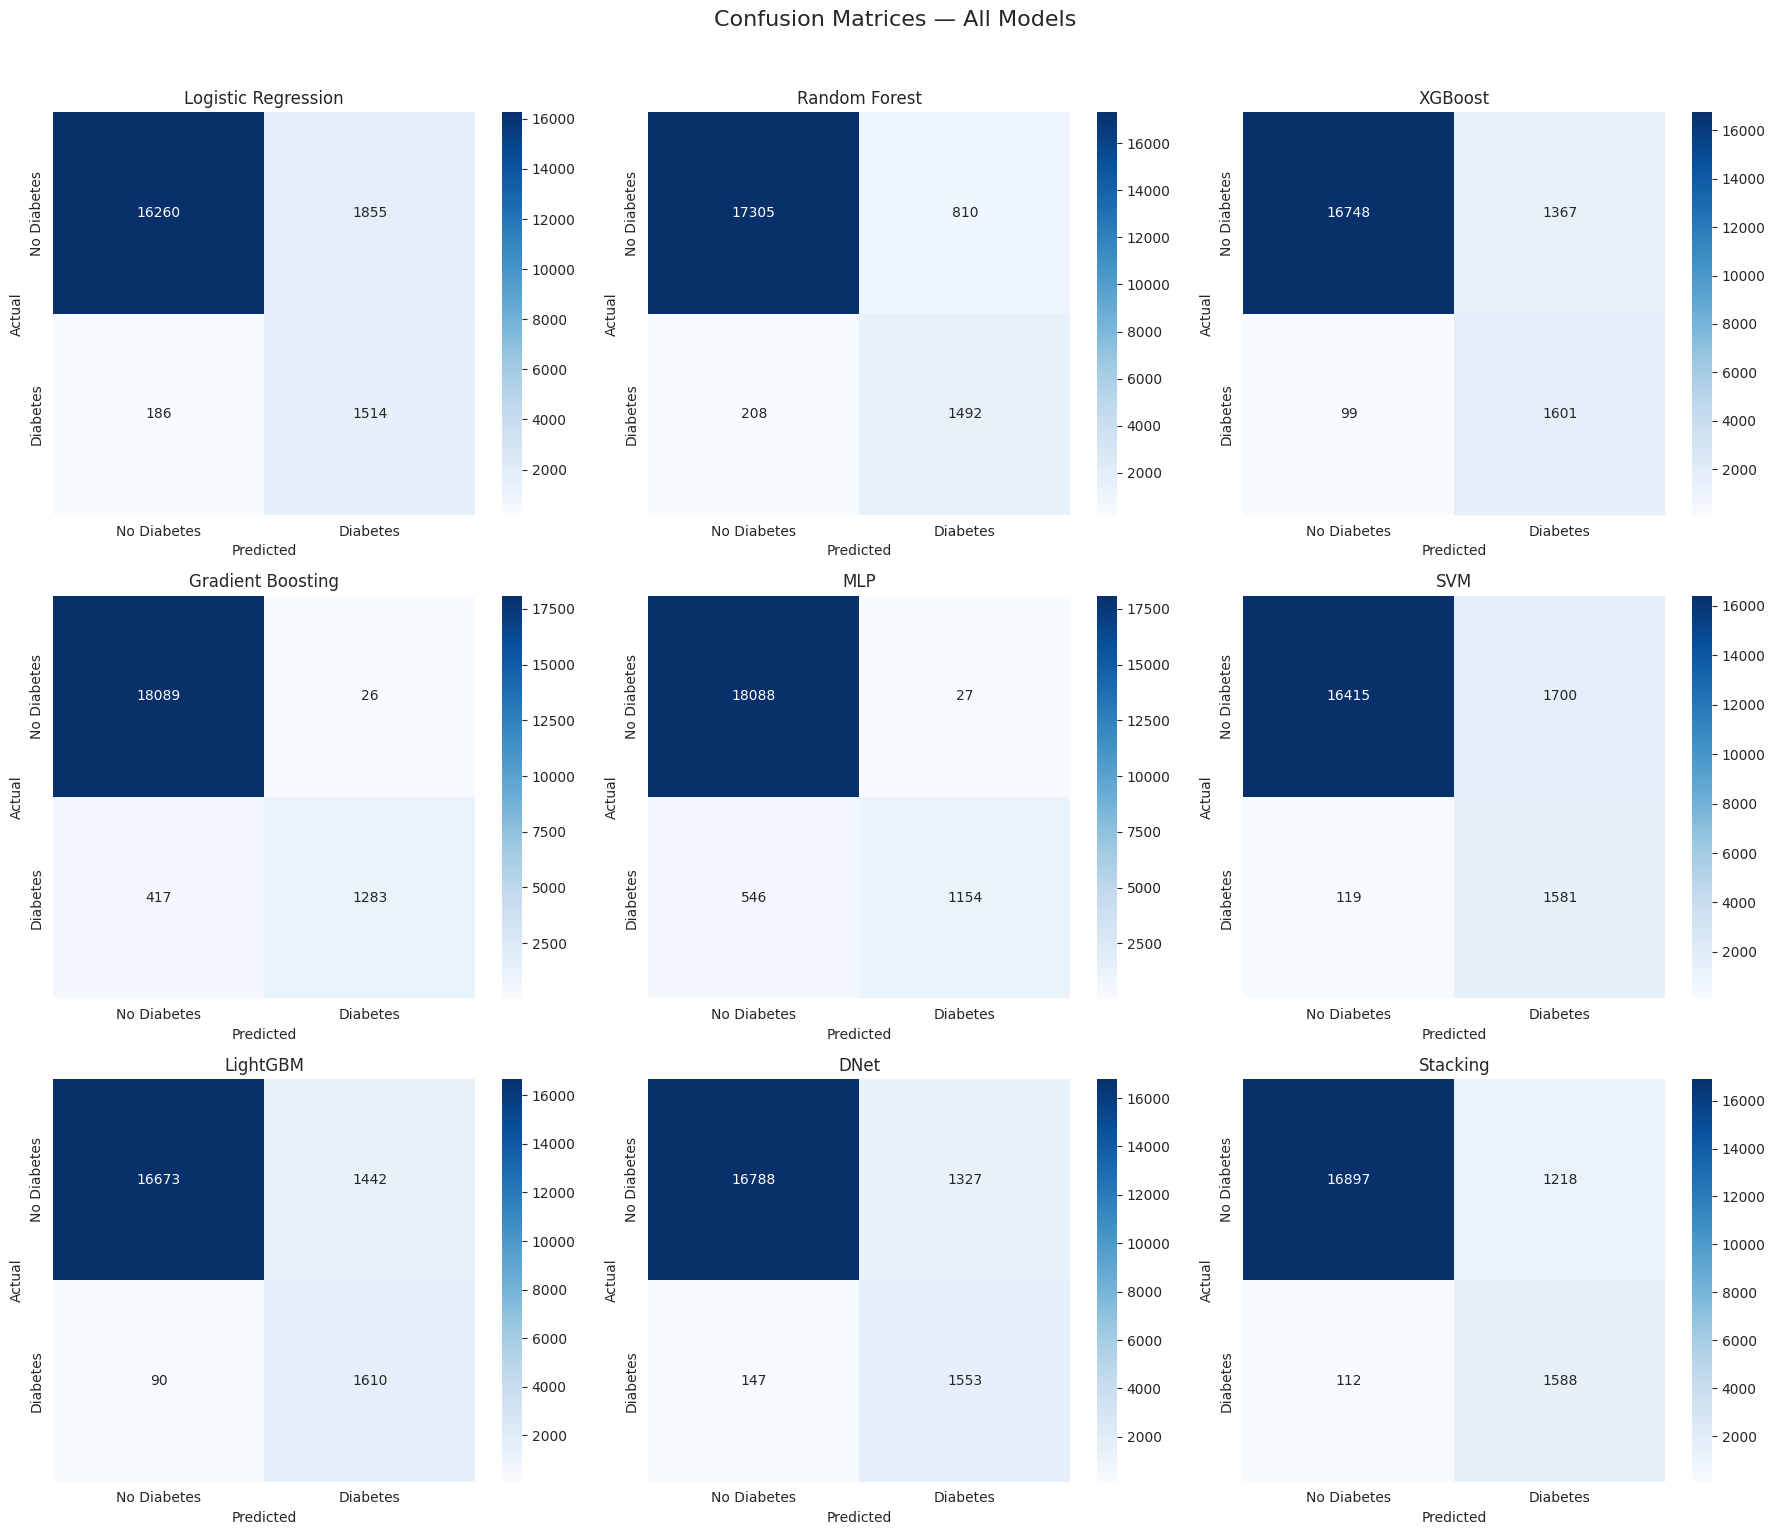

In [ ]:
models_all = [
    ('Logistic Regression', lr,    y_pred_lr,    y_prob_lr),
    ('Random Forest',       rf,    y_pred_rf,    y_prob_rf),
    ('XGBoost',            xgb,    y_pred_xgb,   y_prob_xgb),
    ('Gradient Boosting',   gb,    y_pred_gb,    y_prob_gb),
    ('MLP',                mlp,    y_pred_mlp,   y_prob_mlp),
    ('SVM',                svm,    y_pred_svm,   y_prob_svm),
    ('LightGBM',          lgbm,    y_pred_lgbm,  y_prob_lgbm),
    ('DNet',              dnet,    y_pred_dnet,  y_prob_dnet),
    ('Stacking',         stack,    y_pred_stack, y_prob_stack),
]


fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, (name, model, y_pred, y_prob) in enumerate(models_all):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'])
    axes[i].set_title(f'{name}')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — All Models', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

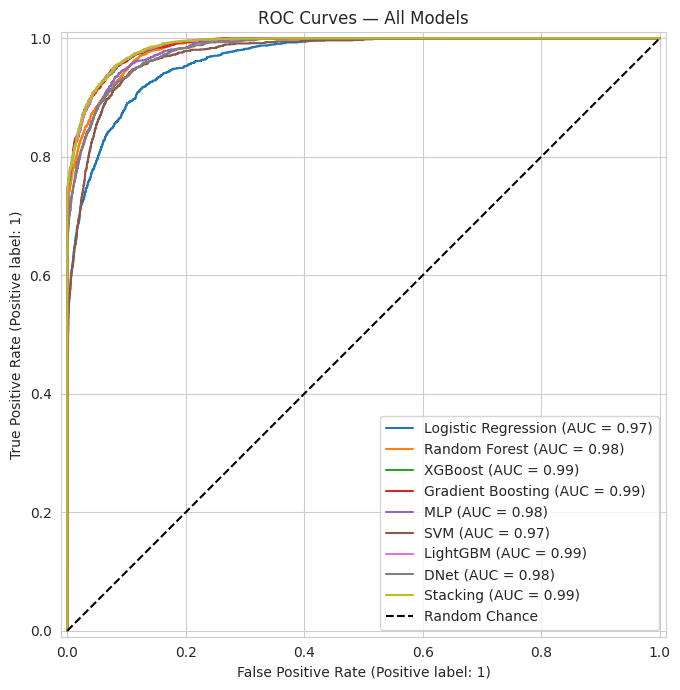

In [ ]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(10, 7))

for name, model, y_pred, y_prob in models_all:
    RocCurveDisplay.from_predictions(
        y_test, y_prob,
        name=name,
        ax=ax
    )

ax.plot([0,1], [0,1], 'k--', label='Random Chance')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
results = []
for name, model, y_pred, y_prob in models_all:
    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).set_index('Model')
print("\nFinal Model Comparison:")
print(results_df.round(4))


Final Model Comparison:
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression    0.8970     0.4494  0.8906  0.5974   0.9655
Random Forest          0.9486     0.6481  0.8776  0.7456   0.9844
XGBoost                0.9260     0.5394  0.9418  0.6859   0.9876
Gradient Boosting      0.9776     0.9801  0.7547  0.8528   0.9877
MLP                    0.9711     0.9771  0.6788  0.8011   0.9826
SVM                    0.9082     0.4819  0.9300  0.6348   0.9748
LightGBM               0.9227     0.5275  0.9471  0.6776   0.9878
DNet                   0.9256     0.5392  0.9135  0.6782   0.9812
Stacking               0.9329     0.5659  0.9341  0.7048   0.9882


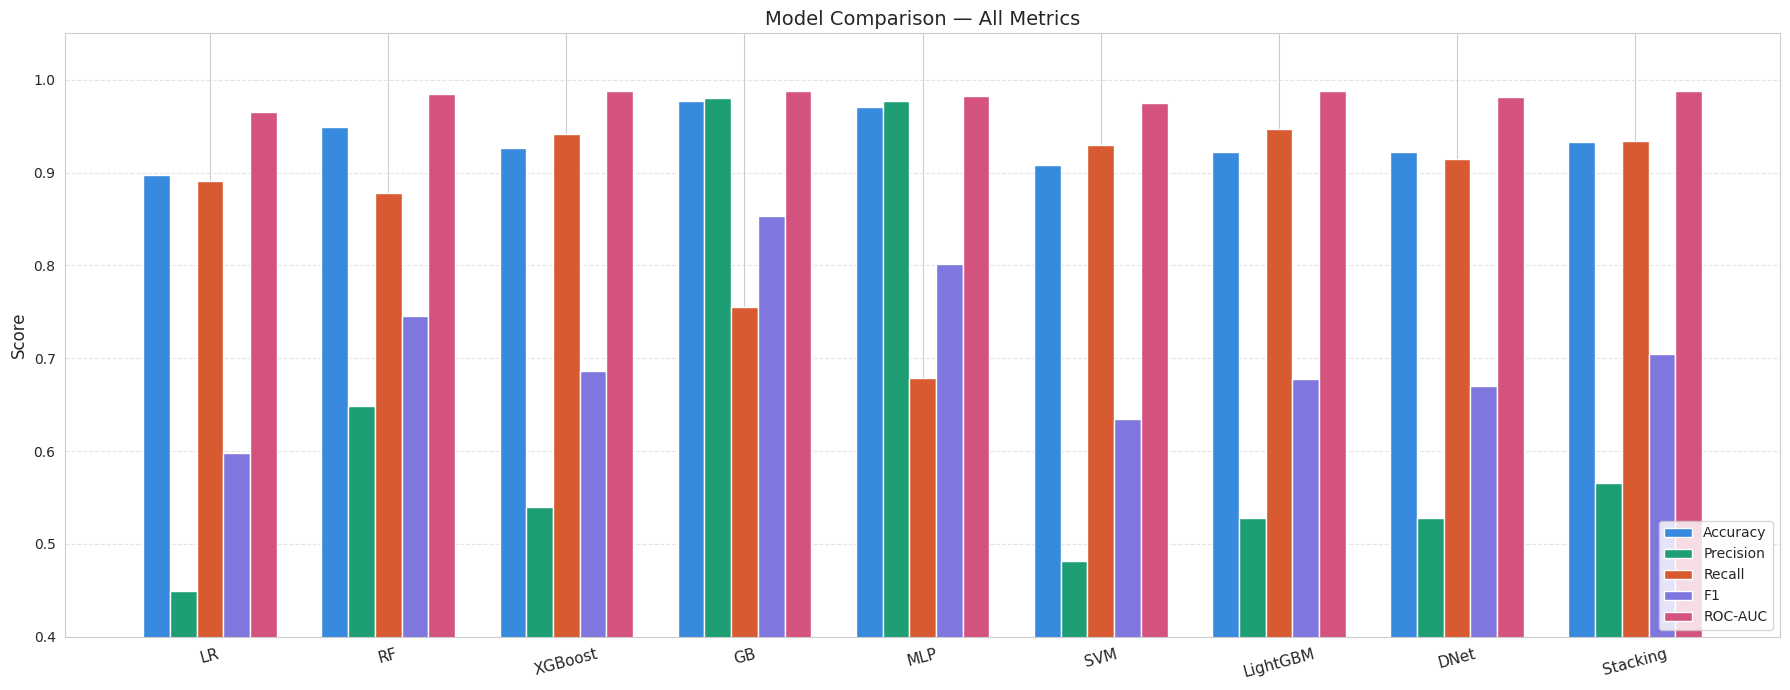

In [ ]:
models = ['LR', 'RF', 'XGBoost', 'GB',
          'MLP', 'SVM', 'LightGBM', 'DNet', 'Stacking']

metrics = {
    'Accuracy':  [0.8970, 0.9486, 0.9260, 0.9776,
                  0.9711, 0.9082, 0.9227, 0.9226, 0.9329],
    'Precision': [0.4494, 0.6481, 0.5394, 0.9801,
                  0.9771, 0.4819, 0.5275, 0.5284, 0.5659],
    'Recall':    [0.8906, 0.8776, 0.9418, 0.7547,
                  0.6788, 0.9300, 0.9471, 0.9141, 0.9341],
    'F1':        [0.5974, 0.7456, 0.6859, 0.8528,
                  0.8011, 0.6348, 0.6776, 0.6697, 0.7048],
    'ROC-AUC':   [0.9655, 0.9844, 0.9876, 0.9877,
                  0.9826, 0.9748, 0.9878, 0.9812, 0.9882]
}

x = np.arange(len(models))
width = 0.15
colors = ['#378ADD', '#1D9E75', '#D85A30', '#7F77DD', '#D4537E']

fig, ax = plt.subplots(figsize=(18, 7))

for i, (metric, values) in enumerate(metrics.items()):
    ax.bar(x + i * width, values, width,
           label=metric, color=colors[i])

ax.set_xticks(x + width * 2)
ax.set_xticklabels(models, fontsize=11, rotation=15)
ax.set_ylim(0.4, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — All Metrics', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()